In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.offline as py
import plotly.graph_objs as go
import plotly.tools as tls
from bs4 import BeautifulSoup
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer , CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
py.init_notebook_mode(connected = True)

In [2]:
train = pd.read_csv('E:\Python Project\ML-projects-\mbti_1.csv')
us = pd.read_csv('Users.csv')
ps = pd.read_csv('E:\Python Project\ML-projects-\ForumMessages.csv')
train.head()
train.shape

C:\Users\Dilan\AppData\Local\Temp\ipykernel_23888\1338146608.py:3: DtypeWarning: Columns (0: MedalAwardDate) have mixed types. Specify dtype option on import or set low_memory=False.
  ps = pd.read_csv('E:\Python Project\ML-projects-\ForumMessages.csv')


(8675, 2)

In [3]:
mbti = {'I' : "Introversion" , 'E': "Extraversion" , 'N' : "Intuition" , 'S' : "Sensing" , 'F' : "Feeling" , 'T' : "Thinking" , 'J' : "Judging" , 'P' : "Perceiving"}

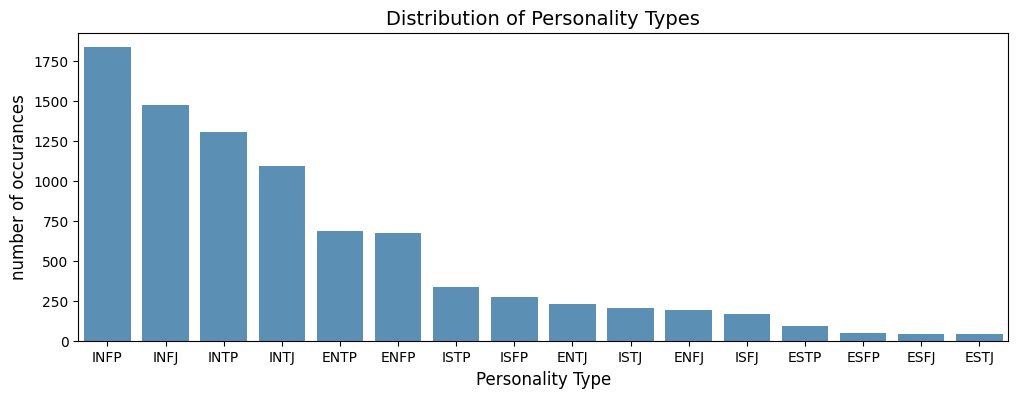

In [4]:
cnt_srs = train['type'].value_counts()
plt.figure(figsize = (12,4))
sns.barplot(x=cnt_srs.index, y=cnt_srs.values, alpha = 0.8)
plt.ylabel("number of occurances" , fontsize = 12)
plt.xlabel("Personality Type" , fontsize = 12)
plt.title("Distribution of Personality Types" , fontsize = 14)
plt.show()

In [5]:
ps['Message'] = ps['Message'].fillna('')


In [6]:
ps_join = ps.groupby('PostUserId')['Message'].agg(lambda col : ''.join(col)).reset_index()

In [7]:
etc = ExtraTreesClassifier(n_estimators = 20 , max_depth = 4 , n_jobs = -1)
tfidf = TfidfVectorizer(ngram_range =(1,1) , stop_words = 'english' )
tsvd = TruncatedSVD(n_components = 10)
model = Pipeline([('tfidf' , tfidf) , ('tsvd' , tsvd) , ('etc' , etc)])

In [8]:
kfolds = StratifiedKFold(n_splits = 5 , shuffle = True , random_state = 1)

In [9]:
np.random.seed(1)

scoring = {'acc':'accuracy' , 'neg_log_loss':'neg_log_loss' , 'f1_micro':'f1_micro'}
results = cross_validate(model , train['posts'] , train['type'] , cv = kfolds , scoring = scoring , n_jobs = -1)

In [10]:
print("cv accuracy :{:0.4f}(+/-{:0.4f}) ".format(np.mean(results['test_acc']), np.std(results['test_acc'])))
print("cv F1 :{:0.4f}(+/-{:0.4f}) ".format(np.mean(results['test_f1_micro']), np.std(results['test_f1_micro'])))
print("cv log loss :{:0.4f}(+/-{:0.4f}) ".format(np.mean(-results['test_neg_log_loss']), np.std(-results['test_neg_log_loss'])))

cv accuracy :0.3010(+/-0.0168) 
cv F1 :0.3010(+/-0.0168) 
cv log loss :2.1426(+/-0.0156) 


In [11]:
def cleanText(text):
    text = BeautifulSoup(text , 'lxml').get_text()
    text = re.sub(r'\|\|\|' , r'' , text)
    text = re.sub(r'http\S+' ,R'<URL>'  , text)
    return text
    

In [12]:
train['clean_posts' ] = train['posts'].apply(cleanText)



In [13]:
np.random.seed(1)
tfidf2 = CountVectorizer(ngram_range = (1,1) , 
                          stop_words = 'english',
                           lowercase = True,
                           max_features = 5000)

model_nb = Pipeline([('tfidf' , tfidf2) , ('nb' , MultinomialNB())])
results_nb = cross_validate(model_nb , train['clean_posts'] , train['type'] , cv = kfolds , scoring = scoring , n_jobs = -1)


In [14]:
print("cv accuracy :{:0.4f}(+/-{:0.4f}) ".format(np.mean(results['test_acc']), np.std(results['test_acc'])))
print("cv F1 :{:0.4f}(+/-{:0.4f}) ".format(np.mean(results['test_f1_micro']), np.std(results['test_f1_micro'])))
print("cv log loss :{:0.4f}(+/-{:0.4f}) ".format(np.mean(-results['test_neg_log_loss']), np.std(-results['test_neg_log_loss'])))

cv accuracy :0.3010(+/-0.0168) 
cv F1 :0.3010(+/-0.0168) 
cv log loss :2.1426(+/-0.0156) 


In [15]:
np.random.seed(1)
tifid2 = CountVectorizer(ngram_range=(1,1) , stop_words = 'english' , lowercase = True , max_features = 5000)
model_lr = Pipeline([('tfidf1' , tfidf2) , ('lr' , LogisticRegression(class_weight = 'balanced' , C= 0.005))])
result_lr = cross_validate(model_lr , train['clean_posts'] , train['type'] , cv = kfolds , scoring = scoring , n_jobs = -1)

In [16]:
train_sizes , train_scores , test_scores = learning_curve(model_lr , train['clean_posts'] , train['type'] , cv = kfolds , n_jobs = -1 , scoring = 'f1_micro' , train_sizes = np.linspace(.1 , 1.0 ,) , random_state = 1)

In [17]:
def plot_learning_curve(x ,y, train_sizes , train_scores , test_scores , title='' , ylim=None , figsize=(14,8)):
    plt.figure(figsize=figsize)
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("training examples")
    plt.ylabel("score")


    train_scores_mean = np.mean(train_scores , axis = 1)
    train_score_std = np.std(train_scores , axis=1)
    test_score_mean = np.mean(test_scores , axis=1)
    test_score_std = np.mean(test_scores , axis=1)
    plt.grid()

    plt.fill_between(train_sizes , train_scores_mean - train_score_std , train_scores_mean + train_score_std , alpha = 0.1 , color = 'g')
    plt.plot(train_sizes , train_scores_mean , 'o-' , color = 'r' , label = "Training score")
    plt.plot(train_sizes , test_score_mean , 'o-' , color = 'g' , label = 'Cross-validation score')

    plt.legend(loc = "best")
    return plt

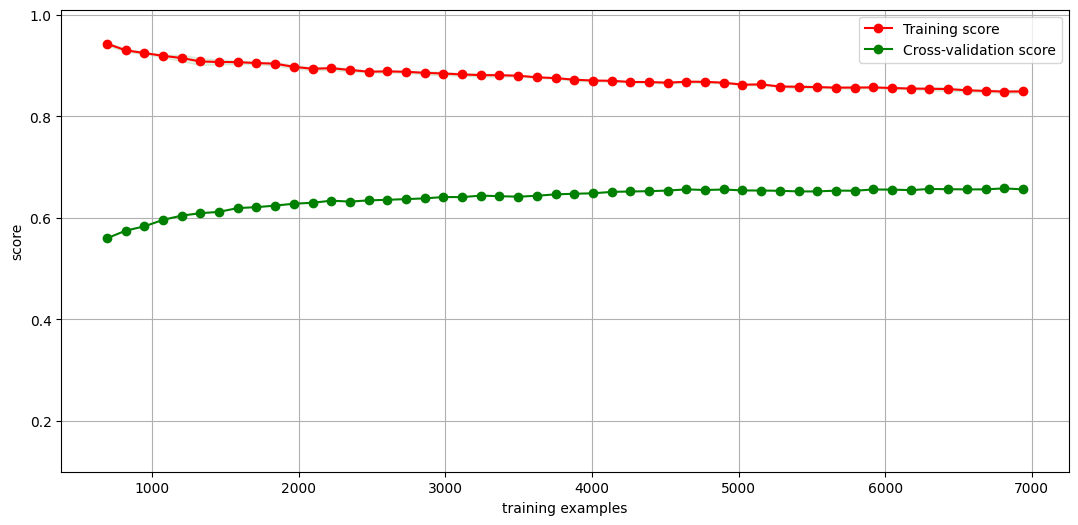

In [18]:
plot_learning_curve(train['posts'] , train['type'] , train_sizes , train_scores , test_scores , ylim = (0.1 , 1.01) , figsize = (13, 6 ))
plt.show()

In [19]:
ps_join['clean_comments'] = ps_join['Message'].apply(cleanText)

In [20]:
model_lr.fit(train['clean_posts'] , train['type'])
pred_all = model_lr.predict(ps_join['clean_comments'])

C:\Users\Dilan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<function matplotlib.pyplot.show(close=None, block=None)>

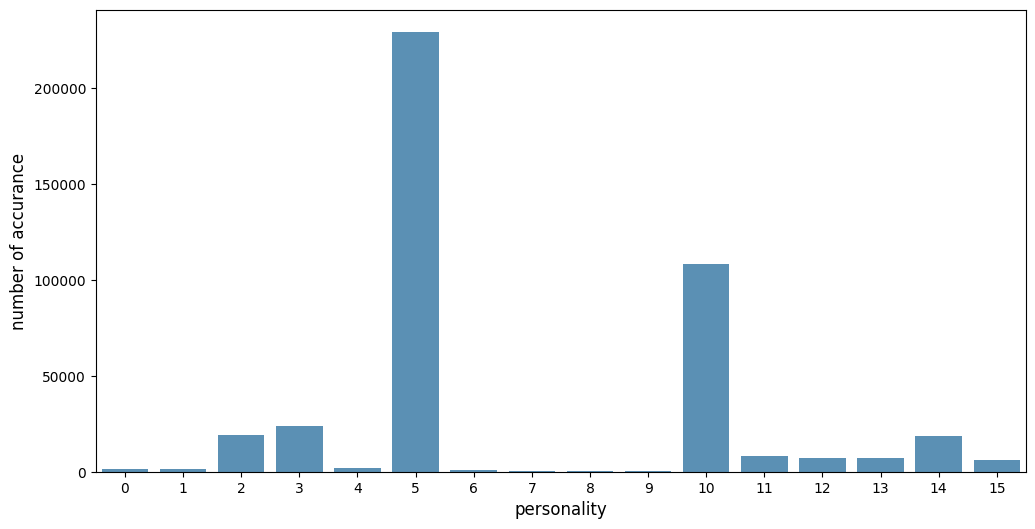

In [24]:
cnt_all = np.unique(pred_all , return_counts = True)
pred_df = pd.DataFrame({'personality' : cnt_all[0] , 'count': cnt_all[1] } , columns = ['personality' , 'count'] , index = None)
pred_df.sort_values('count' ,ascending= False , inplace = True )

plt.figure(figsize = (12,6))
sns.barplot( pred_df['count'] , alpha = 0.8)
plt.ylabel('number of accurance'  ,fontsize = 12)
plt.xlabel('personality' , fontsize = 12)
plt.show

In [25]:
pred_df['percent'] = pred_df['count']/pred_df['count'].sum()

In [30]:
# This will return a blank space for missing keys instead of crashing
pred_df['description'] = pred_df['personality'].apply(lambda x: " ".join([mbti.get(l, "") for l in list(x)]).strip())

In [31]:
pred_df

,personality,count,percent,description
5,ESFP,229522,0.527078,Extraversion Sensing Feeling Perceiving
10,INTJ,108534,0.249239,Introversion Intuition Thinking Judging
3,ENTP,24102,0.055348,Extraversion Intuition Thinking Perceiving
2,ENTJ,19172,0.044027,Extraversion Intuition Thinking Judging
14,ISTJ,18792,0.043154,Introversion Sensing Thinking Judging
11,INTP,8238,0.018918,Introversion Intuition Thinking Perceiving
13,ISFP,7195,0.016523,Introversion Sensing Feeling Perceiving
12,ISFJ,7179,0.016486,Introversion Sensing Feeling Judging
15,ISTP,5998,0.013774,Introversion Sensing Thinking Perceiving
4,ESFJ,1784,0.004097,Extraversion Sensing Feeling Judging


In [ ]:
labels = pred_df['description']
size = pred_df['percent']*180

trace = go.Pie(labels = labels , values = size)
layout  = go.Layout(title = 'kaggle user persanality distribution')


TypeError: 'module' object is not callable